In [1]:
import pandas as pd
import numpy as np

In [4]:
import numpy
import pandas
import sklearn
import scipy

print(numpy.__version__)
print(pandas.__version__)
print(sklearn.__version__)
print(scipy.__version__)

1.21.5
1.4.2
1.0.2
1.7.3


In [5]:
import sys
print(sys.executable)

/opt/conda/envs/anaconda-2022.05-py39/bin/python


In [6]:
import pandas as pd

df = pd.read_csv("spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
import pandas as pd

df = pd.read_csv("spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [9]:
df.shape

(5572, 5)

In [10]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [11]:
df.drop(
    columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],
    inplace=True
)

In [12]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
df.rename(
    columns={
        'v1': 'target',
        'v2': 'text'
    },
    inplace=True
)

In [14]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [16]:
df.duplicated().sum()

403

In [17]:
df = df.drop_duplicates(keep='first')

In [18]:
df.shape

(5169, 2)

In [19]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['target'] = encoder.fit_transform(df['target'])

In [20]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [21]:
df['target'].value_counts()

0    4516
1     653
Name: target, dtype: int64

In [22]:
df['target'].value_counts()cd "/Users/deveshpatel/Documents/SpamDetector"

0    4516
1     653
Name: target, dtype: int64

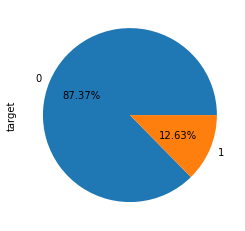

In [23]:
import matplotlib.pyplot as plt

df['target'].value_counts().plot(
    kind='pie',
    autopct='%0.2f%%'
)

plt.show()

In [24]:
pip install nltk

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [25]:
pip install nltk

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [26]:
import nltk

nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /home/d725a3f2-cb1a-47f8-9a2f-6fa46aa7d721/nltk_data..
[nltk_data]     .
[nltk_data]   Package punkt is already up-to-date!


True

In [27]:
df['num_characters'] = df['text'].apply(len)

In [28]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [29]:
df['num_words'] = df['text'].apply(
    lambda x: len(nltk.word_tokenize(x))
)

In [30]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [31]:
df['num_sentences'] = df['text'].apply(
    lambda x: len(nltk.sent_tokenize(x))
)

In [32]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [33]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.453279,1.947185
std,58.236293,13.324793,1.362406
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,28.000000


In [34]:
df[df['target'] == 0][
    ['num_characters',
     'num_words',
     'num_sentences']
].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.120903,1.799601
std,56.358207,13.493725,1.278465
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,28.000000


In [35]:
df[df['target'] == 1][
    ['num_characters',
     'num_words',
     'num_sentences']
].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.967841
std,30.137753,7.008418,1.483201
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,8.000000


In [36]:
df[df['target'] == 1][
    ['num_characters',
     'num_words',
     'num_sentences']
].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.967841
std,30.137753,7.008418,1.483201
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,8.000000


In [37]:
import seaborn as sns

<AxesSubplot:xlabel='num_characters', ylabel='Count'>

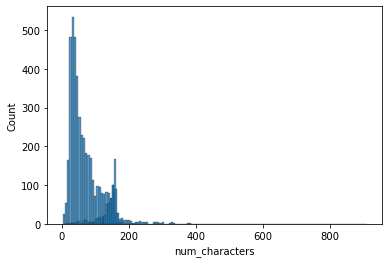

In [38]:
sns.histplot(
    df[df['target'] == 0]['num_characters']
)

sns.histplot(
    df[df['target'] == 1]['num_characters'],
)

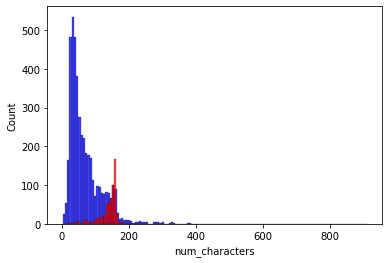

In [39]:
sns.histplot(
    df[df['target'] == 0]['num_characters'],
    color='blue'
)

sns.histplot(
    df[df['target'] == 1]['num_characters'],
    color='red'
)

plt.show()

In [41]:
plt.show()

In [42]:
numeric_df = df[['target','num_characters','num_words','num_sentences']]

numeric_df.corr()

,target,num_characters,num_words,num_sentences
target,1.000000,0.384717,0.262984,0.284901
num_characters,0.384717,1.000000,0.965770,0.638143
num_words,0.262984,0.965770,1.000000,0.684541
num_sentences,0.284901,0.638143,0.684541,1.000000


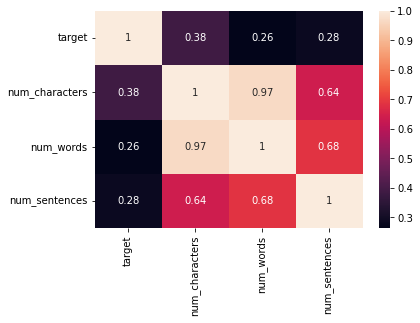

In [43]:
sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.show()

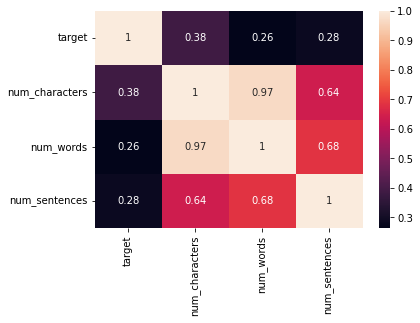

In [44]:
sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.show()

In [45]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/d725a3f2-cb1a-47f8-9a2f-6fa46aa7d721/nltk_data..
[nltk_data]     .
[nltk_data]   Package stopwords is already up-to-date!


True

In [46]:
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

In [47]:
def transform_text(text):

    text = text.lower()

    text = nltk.word_tokenize(text)

    y = []

    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [48]:
transform_text(
    "I loved this video. How about you?"
)

'love video'

In [49]:
df['transformed_text'] = df['text'].apply(transform_text)

In [50]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [85]:
spam_corpus = []

for msg in df[df['target'] == 1]['transformed_text'].tolist():

    for word in msg.split():
        spam_corpus.append(word)

In [84]:
len(spam_corpus)

9939

In [53]:
from collections import Counter

Counter(spam_corpus).most_common(30)

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

In [54]:
common_spam = pd.DataFrame(
    Counter(spam_corpus).most_common(30)
)

common_spam.head()

,0,1
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122


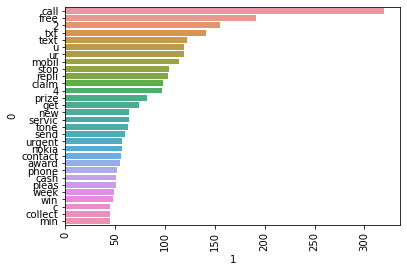

In [55]:
sns.barplot(
    x=common_spam[1],
    y=common_spam[0]
)

plt.xticks(rotation='vertical')

plt.show()

In [56]:
ham_corpus = []

for msg in df[df['target'] == 0]['transformed_text'].tolist():

    for word in msg.split():
        ham_corpus.append(word)

In [57]:
common_ham = pd.DataFrame(
    Counter(ham_corpus).most_common(30)
)

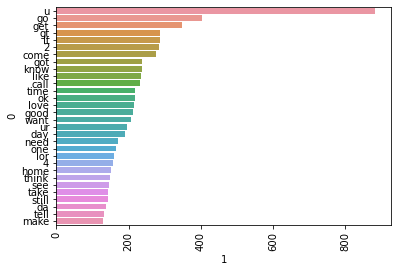

In [58]:
sns.barplot(
    x=common_ham[1],
    y=common_ham[0]
)

plt.xticks(rotation='vertical')

plt.show()

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

In [60]:
X = tfidf.fit_transform(
    df['transformed_text']
).toarray()

y = df['target'].values

In [61]:
from sklearn.model_selection import train_test_split

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)

In [63]:
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

In [64]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [65]:
gnb.fit(X_train, y_train)

y_pred1 = gnb.predict(X_test)

In [66]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score

print(accuracy_score(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.8694390715667312
0.5068493150684932


In [67]:
mnb.fit(X_train, y_train)

y_pred2 = mnb.predict(X_test)

In [68]:
print(accuracy_score(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.9709864603481625
1.0


In [69]:
bnb.fit(X_train, y_train)

y_pred3 = bnb.predict(X_test)

In [70]:
print(accuracy_score(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.9835589941972921
0.991869918699187


In [71]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [72]:
input_sms = "Congratulations! You won a free iPhone."

In [73]:
transformed_sms = transform_text(input_sms)

In [86]:
vector_input = tfidf.transform(
    [transformed_sms]
).toarray()

In [87]:
result = model.predict(vector_input)[0]

if result == 1:
    print("Spam")
else:
    print("Not Spam")

Not Spam


In [88]:
import pickle

pickle.dump(
    tfidf,
    open('vectorizer.pkl', 'wb')
)

pickle.dump(
    model,
    open('model.pkl', 'wb')
)

In [77]:
import os

print(os.getcwd())
print(os.listdir())

/var/www/filebrowser/.projects/7dfc51cf-95ee-40ba-8d6e-bbd3053db327
['spam-detection.ipynb', '.ipynb_checkpoints', 'model.pkl', 'spam.csv', 'vectorizer.pkl', 'spam-comment']


In [78]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /home/d725a3f2-cb1a-47f8-9a2f-6fa46aa7d721/nltk_data..
[nltk_data]     .
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/d725a3f2-cb1a-47f8-9a2f-6fa46aa7d721/nltk_data..
[nltk_data]     .
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/d725a3f2-cb1a-47f8-9a2f-6fa46aa7d721/nltk_data..
[nltk_data]     .
[nltk_data]   Package stopwords is already up-to-date!


True

In [82]:
conda update numpy pandas scipy scikit-learn


CondaValueError: You have chosen a non-default solver backend (libmamba) but it was not recognized. Choose one of: classic


Note: you may need to restart the kernel to use updated packages.


In [83]:
import sys
print(sys.executable)

/opt/conda/envs/anaconda-2022.05-py39/bin/python


In [89]:
import streamlit as st
import pickle
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

ps = PorterStemmer()

model = pickle.load(open('model.pkl', 'rb'))
tfidf = pickle.load(open('vectorizer.pkl', 'rb'))

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []

    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

st.title("Spam Comment Detector")

input_sms = st.text_area("Enter Message")

if st.button("Predict"):
    transformed_sms = transform_text(input_sms)

    vector_input = tfidf.transform([transformed_sms]).toarray()

    result = model.predict(vector_input)[0]

    if result == 1:
        st.error("🚨 Spam Message")
    else:
        st.success("✅ Not Spam")

[nltk_data] Downloading package punkt to
[nltk_data]     /home/d725a3f2-cb1a-47f8-9a2f-6fa46aa7d721/nltk_data..
[nltk_data]     .
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/d725a3f2-cb1a-47f8-9a2f-6fa46aa7d721/nltk_data..
[nltk_data]     .
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/d725a3f2-cb1a-47f8-9a2f-6fa46aa7d721/nltk_data..
[nltk_data]     .
[nltk_data]   Package stopwords is already up-to-date!
2026-06-03 17:51:09.520 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-03 17:51:09.773 
  command:

    streamlit run /opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-06-03 17:51:09.773 Thread 'MainThread': missing ScriptRunContext! This warning can be igno

In [92]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.
